# Step 2. 데이터 품질 점검

- 범위: 2024-01-02 ~ 2026-06-30(워밍업 + 학습). 검증 구간 이후는 읽지 않는다.
- 점검 항목: 중복, 결측, 가격 0·음수, OHLC 논리 위반, 거래량 0·거래정지, 가격제한폭(±30%) 초과, 상·하한가 빈도, 비정상 꼬리(스파이크), 수정주가 여부, 거래일 캘린더, 수급 테이블 정합성.
- 표본 비율은 Step 1 유니버스(`universe_train.parquet`)의 분석 표본(2024-04-01~) 기준이다.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import load_table
from src import plotting as P

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
P.setup()

S, E = "2024-01-01", "2026-06-30"
SAMPLE_START = "2024-04-01"
NXT_START = "2025-03-04"   # 대체거래소(넥스트레이드) 출범일
PRICE = ["open_price", "high_price", "low_price", "close_price"]


def tick(p):
    # 2023-01-25 이후 KRX 유가증권 호가 단위
    return np.select([p < 2000, p < 5000, p < 20000, p < 50000, p < 200000, p < 500000],
                     [1, 5, 10, 50, 100, 500], 1000)

c = load_table("stock_daily_candles", S, E).sort_values(["symbol", "trade_date"]).reset_index(drop=True)
idx = load_table("market_indicator_daily_candles", S, E)
kospi = idx[idx.symbol == "KOSPI"].sort_values("trade_date").set_index("trade_date")
uni = pd.read_parquet(ROOT / "data" / "cache" / "universe_train.parquet")
uni_s = uni[uni.in_sample]
cal = pd.DatetimeIndex(sorted(c.trade_date.unique()))
print(f"일봉 {len(c):,}행, {c.symbol.nunique()}종목, {len(cal)}거래일 | 분석 표본 {len(uni_s):,}쌍")

일봉 137,269행, 229종목, 606거래일 | 분석 표본 108,172쌍


## 1. 중복·결측·가격 0 이하·OHLC 논리 위반

In [2]:
c["prev_close"] = c.groupby("symbol")["close_price"].shift()
checks = pd.Series({
    "중복 (종목, 일자)": c.duplicated(["symbol", "trade_date"]).sum(),
    "NULL 값": int(c[PRICE + ["volume"]].isna().sum().sum()),
    "가격 0 이하": int((c[PRICE] <= 0).any(axis=1).sum()),
    "거래량 음수": int((c.volume < 0).sum()),
    "High < Low": int((c.high_price < c.low_price).sum()),
    "High < max(Open, Close)": int((c.high_price < c[["open_price", "close_price"]].max(axis=1)).sum()),
    "Low > min(Open, Close)": int((c.low_price > c[["open_price", "close_price"]].min(axis=1)).sum()),
    "adjusted != 1": int((c.adjusted != 1).sum()),
})
checks.to_frame("건수")

,건수
"중복 (종목, 일자)",0
NULL 값,0
가격 0 이하,0
거래량 음수,0
High < Low,0
"High < max(Open, Close)",0
"Low > min(Open, Close)",0
adjusted != 1,0


In [3]:
# 종목별로 첫~마지막 일봉 사이에 빠진 거래일
gaps = {s: len(cal[(cal >= g.trade_date.min()) & (cal <= g.trade_date.max())]) - len(g) for s, g in c.groupby("symbol")}
gaps = {k: v for k, v in gaps.items() if v}
print("중간에 빠진 거래일이 있는 종목:", gaps if gaps else "없음")
first = c.groupby("symbol").trade_date.min()
print("2024-01-02보다 늦게 시작하는 종목(신규 상장):", first[first > cal.min()].dt.date.to_dict())

중간에 빠진 거래일이 있는 종목: 없음
2024-01-02보다 늦게 시작하는 종목(신규 상장): {'0126Z0': datetime.date(2025, 11, 24), '062040': datetime.date(2024, 7, 29), '064400': datetime.date(2025, 2, 5), '278470': datetime.date(2024, 2, 27), '443060': datetime.date(2024, 5, 8), '483650': datetime.date(2025, 5, 22), '489790': datetime.date(2024, 9, 27)}


## 2. 거래일 캘린더

In [4]:
bd = pd.bdate_range(S, E)
missing_weekdays = bd.difference(cal)
print("주말 거래일:", int((cal.weekday >= 5).sum()))
print(f"캘린더에 없는 평일 {len(missing_weekdays)}일:")
print(", ".join(d.strftime("%Y-%m-%d") for d in missing_weekdays))
k_cal = kospi.index
print("KOSPI 지수와 종목 일봉의 거래일 차이:", len(cal.symmetric_difference(k_cal)))
per_day = c.groupby("trade_date").size()
print("일자별 종목 수: 최소", per_day.min(), "최대", per_day.max())

주말 거래일: 0
캘린더에 없는 평일 46일:
2024-01-01, 2024-02-09, 2024-02-12, 2024-03-01, 2024-04-10, 2024-05-01, 2024-05-06, 2024-05-15, 2024-06-06, 2024-08-15, 2024-09-16, 2024-09-17, 2024-09-18, 2024-10-01, 2024-10-03, 2024-10-09, 2024-12-25, 2024-12-31, 2025-01-01, 2025-01-27, 2025-01-28, 2025-01-29, 2025-01-30, 2025-03-03, 2025-05-01, 2025-05-05, 2025-05-06, 2025-06-03, 2025-06-06, 2025-08-15, 2025-10-03, 2025-10-06, 2025-10-07, 2025-10-08, 2025-10-09, 2025-12-25, 2025-12-31, 2026-01-01, 2026-02-16, 2026-02-17, 2026-02-18, 2026-03-02, 2026-05-01, 2026-05-05, 2026-05-25, 2026-06-03
KOSPI 지수와 종목 일봉의 거래일 차이: 0
일자별 종목 수: 최소 222 최대 229


## 3. 거래량 0 (거래정지)

In [5]:
z = c[c.volume == 0].copy()
z["flat_prev"] = (z[PRICE].eq(z.prev_close, axis=0)).all(axis=1)
print(f"거래량 0: {len(z)}행, {z.symbol.nunique()}종목. 이 중 OHLC가 모두 전일 종가와 같은 행 {z.flat_prev.sum()}")
# 연속 구간으로 묶기
z["pos"] = z.trade_date.map({d: i for i, d in enumerate(cal)})
z["run"] = (z.groupby("symbol").pos.diff() != 1).cumsum()
runs = z.groupby(["symbol", "run"]).agg(start=("trade_date", "min"), end=("trade_date", "max"), days=("pos", "size")).reset_index()
names = pd.read_parquet(ROOT / "data" / "cache" / "stocks.parquet") if (ROOT / "data" / "cache" / "stocks.parquet").exists() else None
if names is None:
    from src.db import read_sql
    names = read_sql("SELECT symbol, name FROM stocks")
    names.to_parquet(ROOT / "data" / "cache" / "stocks.parquet", index=False)
nm = names.set_index("symbol")["name"]
runs["name"] = runs.symbol.map(nm)
# 재개 첫날 수익률(수정주가가 제대로 되어 있으면 분할 재상장에서도 비정상 점프가 작아야 한다)
nxt = c.set_index(["symbol", "trade_date"])
def resume_ret(r):
    after = cal[cal > r.end]
    if len(after) == 0:
        return np.nan
    row = nxt.loc[(r.symbol, after[0])] if (r.symbol, after[0]) in nxt.index else None
    return np.nan if row is None else row.close_price / row.prev_close - 1
runs["resume_day_ret"] = runs.apply(resume_ret, axis=1).round(4)
# 분석 표본 내 거래량 0 쌍
zs = uni_s.merge(z[["symbol", "trade_date"]], on=["symbol", "trade_date"])
print(f"분석 표본 중 거래량 0: {len(zs)}쌍")
runs.sort_values("start")[["symbol", "name", "start", "end", "days", "resume_day_ret"]]

거래량 0: 440행, 12종목. 이 중 OHLC가 모두 전일 종가와 같은 행 437


분석 표본 중 거래량 0: 105쌍


,symbol,name,start,end,days,resume_day_ret
14,457190,이수스페셜티케미컬,2024-04-23,2024-04-30,6,-0.1016
5,004800,효성,2024-06-27,2024-07-26,22,0.1112
9,012450,한화에어로스페이스,2024-08-29,2024-09-26,18,0.0566
7,007340,DN오토모티브,2024-09-25,2024-10-07,7,-0.0612
11,278470,에이피알,2024-10-18,2024-10-30,9,-0.0600
1,001570,금양,2024-10-29,2024-10-29,1,-0.1327
6,007070,GS리테일,2024-11-28,2024-12-20,17,-0.0419
2,001570,금양,2025-03-05,2025-03-05,1,-0.2611
3,001570,금양,2025-03-24,2026-06-30,310,NaN
4,003620,KG모빌리티,2025-04-10,2025-05-08,18,-0.0287


## 4. 가격제한폭과 비정상 꼬리(스파이크)

KRX 가격제한폭은 전일 종가 대비 ±30%다. 수정주가는 전일과 당일에 같은 조정 계수를 곱하므로, 수정주가에서도 비율은 대체로 유지된다(기준가가 재설정되는 기업 이벤트일은 예외).

- **제한폭 초과**: O/H/L/C 중 하나가 전일 종가 대비 ±30.5%를 넘는 행
- **스파이크**: 종가는 전일 대비 ±5% 이내인데, 저가가 min(전일 종가, 종가)보다 15% 이상 낮거나(**저가 스파이크**), 고가가 max(전일 종가, 종가)보다 15% 이상 높은(**고가 스파이크**) 행

In [6]:
v = c[(c.volume > 0) & c.prev_close.notna()].copy()
for k, col in {"r_open": "open_price", "r_high": "high_price", "r_low": "low_price", "r_close": "close_price"}.items():
    v[k] = v[col] / v.prev_close - 1
v["wick_lo"] = v.low_price / np.minimum(v.prev_close, v.close_price) - 1
v["wick_hi"] = v.high_price / np.maximum(v.prev_close, v.close_price) - 1
v["lo_spike"] = (v.wick_lo < -0.15) & (v.r_close.abs() < 0.05)
v["hi_spike"] = (v.wick_hi > 0.15) & (v.r_close.abs() < 0.05)
v["beyond_limit"] = (v[["r_open", "r_high", "r_low", "r_close"]].abs() > 0.305).any(axis=1)

lim = pd.Series({
    "종가 상한가 근처 (≥ +29%)": int((v.r_close >= 0.29).sum()),
    "종가 하한가 근처 (≤ -29%)": int((v.r_close <= -0.29).sum()),
    "고가 상한가 터치 (≥ +29%)": int((v.r_high >= 0.29).sum()),
    "저가 하한가 터치 (≤ -29%)": int((v.r_low <= -0.29).sum()),
    "제한폭 초과 행 (±30.5%)": int(v.beyond_limit.sum()),
    "저가 스파이크": int(v.lo_spike.sum()),
    "고가 스파이크": int(v.hi_spike.sum()),
})
lim.to_frame("건수 (거래량>0 행)")

,건수 (거래량>0 행)
종가 상한가 근처 (≥ +29%),68
종가 하한가 근처 (≤ -29%),2
고가 상한가 터치 (≥ +29%),144
저가 하한가 터치 (≤ -29%),58
제한폭 초과 행 (±30.5%),28
저가 스파이크,91
고가 스파이크,120


In [7]:
# 종가가 제한폭을 넘는 행: 기업 이벤트(기준가 재설정) 또는 수정주가 누락 후보
v.loc[v.r_close.abs() > 0.305, ["symbol", "trade_date", "prev_close", "open_price", "high_price", "low_price", "close_price", "volume", "r_close"]] \
 .assign(name=lambda d: d.symbol.map(nm))

,symbol,trade_date,prev_close,open_price,high_price,low_price,close_price,volume,r_close,name
9564,001430,2025-12-12,34250.0,34650.0,44750.0,34650.0,44750.0,3081034.0,0.306569,세아베스틸지주
30193,005850,2026-01-21,48550.0,49500.0,64800.0,47800.0,64800.0,3049633.0,0.334706,에스엘
49670,011070,2026-05-29,1120000.0,1172000.0,1474000.0,1145000.0,1474000.0,2839913.0,0.316071,LG이노텍
52684,011790,2026-05-06,123400.0,125000.0,161200.0,124000.0,161200.0,6361503.0,0.306321,SKC
62408,020150,2025-11-10,24450.0,24650.0,32000.0,24150.0,32000.0,2699928.0,0.308793,롯데에너지머티리얼즈
94216,079550,2026-04-01,608000.0,633000.0,794000.0,620000.0,794000.0,1768284.0,0.305921,LIG디펜스앤에어로스페이스
120253,272210,2026-03-03,112700.0,117500.0,147600.0,117400.0,147600.0,25473359.0,0.309672,한화시스템
123220,298020,2026-01-21,289000.0,301000.0,379500.0,285500.0,379500.0,326573.0,0.313149,효성티앤씨
126240,307950,2026-01-07,308500.0,308500.0,405500.0,308500.0,405500.0,4726729.0,0.314425,현대오토에버
129349,336260,2026-05-06,60300.0,61000.0,78700.0,58900.0,78700.0,8905022.0,0.305141,두산퓨얼셀


In [8]:
# 꼬리 깊이 분포: 종가가 전일 대비 ±5% 이내인 날
flat = v[v.r_close.abs() < 0.05]
bins_lo = [-1, -0.25, -0.2, -0.15, -0.12, -0.1, -0.08, -0.06, -0.04, 0]
bins_hi = [0, 0.04, 0.06, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25, 1]
pd.DataFrame({"아래꼬리 구간": pd.cut(flat.wick_lo, bins_lo).value_counts().sort_index().index.astype(str),
              "건수(아래)": pd.cut(flat.wick_lo, bins_lo).value_counts().sort_index().values,
              "위꼬리 구간": pd.cut(flat.wick_hi, bins_hi).value_counts().sort_index().index.astype(str),
              "건수(위)": pd.cut(flat.wick_hi, bins_hi).value_counts().sort_index().values})

,아래꼬리 구간,건수(아래),위꼬리 구간,건수(위)
0,"(-1.0, -0.25]",58,"(0.0, 0.04]",104042
1,"(-0.25, -0.2]",10,"(0.04, 0.06]",2949
2,"(-0.2, -0.15]",23,"(0.06, 0.08]",823
3,"(-0.15, -0.12]",25,"(0.08, 0.1]",294
4,"(-0.12, -0.1]",34,"(0.1, 0.12]",124
5,"(-0.1, -0.08]",117,"(0.12, 0.15]",102
6,"(-0.08, -0.06]",380,"(0.15, 0.2]",54
7,"(-0.06, -0.04]",1893,"(0.2, 0.25]",31
8,"(-0.04, 0.0]",111497,"(0.25, 1.0]",35


In [9]:
v["period"] = np.where(v.trade_date < NXT_START, "NXT 이전 (~2025-03-03)", "NXT 이후 (2025-03-04~)")
g = v.groupby("period").agg(rows=("symbol", "size"), lo_spike=("lo_spike", "sum"), hi_spike=("hi_spike", "sum"),
                            beyond_limit=("beyond_limit", "sum"))
g["스파이크/1만 행"] = ((g.lo_spike + g.hi_spike) / g.rows * 1e4).round(2)
display(g)
sp = v[v.lo_spike]
print(f"저가 스파이크 중 시가=저가: {(sp.open_price == sp.low_price).mean():.0%}, "
      f"꼬리 깊이 중앙값 {sp.wick_lo.median():.1%}, 종목 수 {sp.symbol.nunique()}")
kl = (kospi.low_price / kospi.close_price.shift() - 1).rename("kospi_low_ret")
sp = sp.join(kl, on="trade_date")
print(f"저가 스파이크 당일 KOSPI 저가가 -3% 이하였던 경우: {(sp.kospi_low_ret < -0.03).sum()}건 / {len(sp)}")

,rows,lo_spike,hi_spike,beyond_limit,스파이크/1만 행
period,,,,,
NXT 이전 (~2025-03-03),62998,1,15,0,2.54
NXT 이후 (2025-03-04~),73602,90,105,28,26.49


저가 스파이크 중 시가=저가: 64%, 꼬리 깊이 중앙값 -27.8%, 종목 수 70
저가 스파이크 당일 KOSPI 저가가 -3% 이하였던 경우: 16건 / 91


In [10]:
# 종가가 상한가(전일 종가 x 1.3을 호가 단위로 내림)를 넘는가: KRX 공식 종가라면 불가능하다
lim_px = v.prev_close * 1.3
lim_px = np.floor(lim_px / tick(lim_px)) * tick(lim_px)
v["above_uplimit"] = v.close_price > lim_px * 1.001
v["nxt"] = v.trade_date >= NXT_START
up = v[v.r_close >= 0.29].groupby("nxt").agg(n=("symbol", "size"), above=("above_uplimit", "sum"))
display(up.rename(index={False: "NXT 이전", True: "NXT 이후"}))

,n,above
nxt,,
NXT 이전,17,0
NXT 이후,51,17


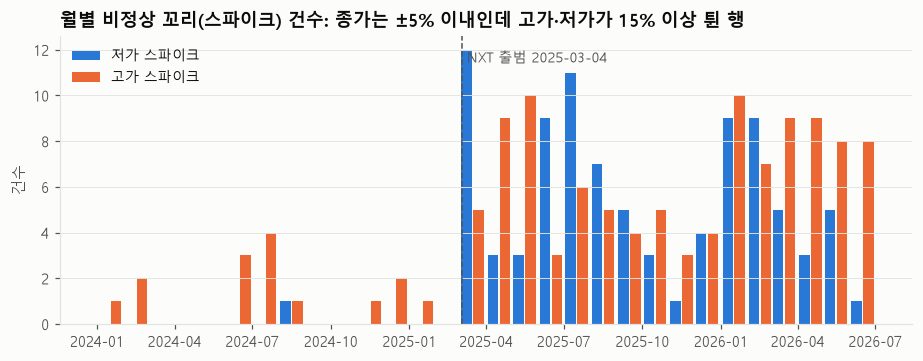

In [11]:
m = v.assign(ym=v.trade_date.dt.to_period("M").dt.to_timestamp()).groupby("ym")[["lo_spike", "hi_spike"]].sum()
fig, ax = plt.subplots(figsize=(10, 3.4))
w = 12
m.index = m.index + pd.Timedelta(days=15)   # 막대를 월 중앙에 둔다
ax.bar(m.index - pd.Timedelta(days=7), m.lo_spike, width=w, color=P.SERIES[0], label="저가 스파이크")
ax.bar(m.index + pd.Timedelta(days=7), m.hi_spike, width=w, color=P.SERIES[1], label="고가 스파이크")
ax.axvline(pd.Timestamp(NXT_START), color=P.TEXT_2, lw=1, ls="--")
ax.text(pd.Timestamp(NXT_START), ax.get_ylim()[1] * 0.95, " NXT 출범 2025-03-04", color=P.TEXT_2, fontsize=9, va="top")
ax.set_ylabel("건수")
ax.set_title("월별 비정상 꼬리(스파이크) 건수: 종가는 ±5% 이내인데 고가·저가가 15% 이상 튄 행")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(axis="x", visible=False)
P.save(fig, "03_quality_spikes_monthly")
plt.show()

In [12]:
# 예시: 저가 스파이크 상위 15건
sp.sort_values("wick_lo")[["symbol", "trade_date", "prev_close", "open_price", "high_price", "low_price", "close_price",
                           "volume", "wick_lo", "kospi_low_ret"]].head(15).assign(name=lambda d: d.symbol.map(nm))

,symbol,trade_date,prev_close,open_price,high_price,low_price,close_price,volume,wick_lo,kospi_low_ret,name
30811,005930,2026-02-06,161100.0,152000.0,161600.0,111600.0,161000.0,55231941.0,-0.306832,-0.051180,삼성전자
5948,000720,2026-01-14,92900.0,64400.0,100100.0,64400.0,94100.0,8812291.0,-0.306781,-0.004969,현대건설
73299,034020,2025-10-16,84300.0,58100.0,86600.0,58100.0,83400.0,18830109.0,-0.303357,0.005069,두산에너빌리티
109793,175330,2025-07-07,21700.0,20650.0,22650.0,15150.0,22400.0,637409.0,-0.301843,-0.006971,JB금융지주
62327,020150,2025-07-10,22250.0,15550.0,23400.0,15550.0,23300.0,282475.0,-0.301124,0.000022,롯데에너지머티리얼즈
130483,361610,2026-01-08,24100.0,16850.0,25200.0,16850.0,24550.0,463622.0,-0.300830,-0.005177,SK아이이테크놀로지
69637,030200,2025-09-03,52200.0,36500.0,53700.0,36500.0,52500.0,282619.0,-0.300766,-0.001614,KT
31200,005940,2025-03-20,15070.0,10510.0,15300.0,10510.0,15030.0,376341.0,-0.300732,0.000221,NH투자증권
69741,030200,2026-02-06,56200.0,39300.0,56900.0,39300.0,56500.0,867259.0,-0.300712,-0.051180,KT
7022,000880,2025-06-23,112367.0,78513.0,114768.0,78513.0,112247.0,701783.0,-0.300534,-0.016705,한화


### 4.1 스파이크가 타깃(MDD_5)에 주는 영향

미리보기로 MDD_5(저가 기준)와 종가 기준 MDD_5를 계산한다. t+5가 2026-06-30 이하인 행만 계산하므로 7월 가격은 쓰지 않는다.
여기서는 t+1~t+5 구간의 최저 저가가 **저가 스파이크 행**에서 나온 표본의 수를 센다.

In [13]:
def fwd_min(s, h=5):
    # t+1..t+h 최솟값 (미래 방향: 타깃 전용)
    return pd.concat([s.shift(-i) for i in range(1, h + 1)], axis=1).min(axis=1, skipna=False)

t = c.merge(v[["symbol", "trade_date", "lo_spike"]], on=["symbol", "trade_date"], how="left").fillna({"lo_spike": False})
t = t.sort_values(["symbol", "trade_date"])
gb = t.groupby("symbol")
t["mdd5_low"] = gb.low_price.transform(fwd_min) / t.close_price - 1
t["mdd5_close"] = gb.close_price.transform(fwd_min) / t.close_price - 1
# 구간 최저 저가가 스파이크 행에서 나왔는지
t["spike_low_val"] = np.where(t.lo_spike, t.low_price, np.inf)
t["min_spike_low"] = gb.spike_low_val.transform(lambda s: fwd_min(s.replace(np.inf, np.nan).fillna(np.inf)))
t["min_from_spike"] = np.isclose(t.min_spike_low, t.mdd5_low.add(1) * t.close_price)
tt = t.merge(uni_s[["symbol", "trade_date"]], on=["symbol", "trade_date"]).dropna(subset=["mdd5_low"])
rows = []
for thr in [0, -0.05, -0.10, -0.15, -0.20]:
    sel = tt[tt.mdd5_low <= thr]
    rows.append({"MDD_5 (저가) ≤": f"{thr:.0%}", "표본": len(sel), "최저가가 스파이크에서 나온 표본": int(sel.min_from_spike.sum()),
                 "비율": f"{sel.min_from_spike.mean():.1%}"})
display(pd.DataFrame(rows))
print(f"계산된 표본 {len(tt):,}쌍 (t+5 ≤ 2026-06-30)")

,MDD_5 (저가) ≤,표본,최저가가 스파이크에서 나온 표본,비율
0,0%,102046,370,0.4%
1,-5%,36026,370,1.0%
2,-10%,11051,369,3.3%
3,-15%,3906,356,9.1%
4,-20%,1511,306,20.3%


계산된 표본 107,172쌍 (t+5 ≤ 2026-06-30)


In [14]:
# 스파이크 영향 표본에서 저가 기준과 종가 기준 MDD_5 비교
aff = tt[tt.min_from_spike]
print(f"영향 표본 {len(aff)}쌍: MDD_5(저가) 중앙값 {aff.mdd5_low.median():.1%}, MDD_5(종가) 중앙값 {aff.mdd5_close.median():.1%}")
print(f"전체 표본: MDD_5(저가) 1% 분위 {tt.mdd5_low.quantile(0.01):.1%}, 영향 표본 제외 시 {tt[~tt.min_from_spike].mdd5_low.quantile(0.01):.1%}")

영향 표본 370쌍: MDD_5(저가) 중앙값 -27.9%, MDD_5(종가) 중앙값 -1.7%
전체 표본: MDD_5(저가) 1% 분위 -21.8%, 영향 표본 제외 시 -20.5%


## 5. 수정주가 여부

1. **호가 단위 검사**: 수정되지 않은 가격은 KRX 호가 단위의 배수여야 한다. 호가 단위와 맞지 않는 가격이 있으면, 이후 기업 이벤트에 맞춰 과거 가격을 소급 조정했다는 증거다.
2. **비정상 점프 검사**: 종가 기준 ±30.5% 초과 수익률(4절 표)과 거래정지 재개일 수익률(3절 표)을 본다.

In [15]:
c["off_tick"] = (c.close_price % tick(c.close_price)) != 0
sym = c.groupby("symbol").agg(off_tick_share=("off_tick", "mean"),
                              last_off_tick=("trade_date", lambda s: s[c.loc[s.index, "off_tick"]].max()))
adj = sym[sym.off_tick_share > 0].sort_values("off_tick_share", ascending=False)
print(f"호가 단위와 맞지 않는 종가가 있는 종목: {len(adj)} / {c.symbol.nunique()}")
display(adj.assign(name=lambda d: d.index.map(nm)).head(20))

호가 단위와 맞지 않는 종가가 있는 종목: 26 / 229


,off_tick_share,last_off_tick,name
symbol,,,
000880,0.991749,2026-06-30,한화
068270,0.958746,2026-06-02,셀트리온
009830,0.955446,2026-06-12,한화솔루션
011790,0.899340,2026-04-03,SKC
006800,0.833333,2026-03-13,미래에셋증권
000670,0.785479,2025-12-26,영풍
207940,0.759076,2025-11-21,삼성바이오로직스
018880,0.630363,2025-11-11,한온시스템
003670,0.574257,2025-06-13,포스코퓨처엠


In [16]:
# 조정 경계일: 마지막 off-tick 다음 거래일이 기업 이벤트일 후보. 그날 수익률이 정상 범위인지 확인
bound = []
for s, r in adj.iterrows():
    after = cal[cal > r.last_off_tick]
    if len(after) == 0:
        continue
    d = after[0]
    row = c[(c.symbol == s) & (c.trade_date == d)]
    if len(row):
        bound.append({"symbol": s, "name": nm.get(s), "event_day": d.date(),
                      "ret": round(float(row.close_price.iloc[0] / row.prev_close.iloc[0] - 1), 4),
                      "volume": int(row.volume.iloc[0])})
bound = pd.DataFrame(bound)
print(f"조정 경계일 {len(bound)}건 중 |수익률| > 30%: {(bound.ret.abs() > 0.3).sum()}건, > 15%: {(bound.ret.abs() > 0.15).sum()}건")
bound.sort_values("ret", key=abs, ascending=False).head(10)

조정 경계일 25건 중 |수익률| > 30%: 0건, > 15%: 1건


,symbol,name,event_day,ret,volume
22,457190,이수스페셜티케미컬,2024-02-06,0.2987,6992660
17,004800,효성,2024-07-29,0.1112,242096
1,009830,한화솔루션,2026-06-15,0.1089,2204978
16,010120,LS ELECTRIC,2025-04-29,0.0821,4109765
24,192080,더블유게임즈,2024-01-17,-0.0665,68487
15,007340,DN오토모티브,2024-10-08,-0.0612,423837
6,018880,한온시스템,2025-11-12,-0.0426,6417096
9,006400,삼성SDI,2025-04-10,0.0411,653016
11,003620,KG모빌리티,2025-04-09,-0.0383,626627
3,006800,미래에셋증권,2026-03-16,0.0333,8785685


## 6. 수급 테이블 정합성 (학습 구간)

In [17]:
pairs = uni_s[["symbol", "trade_date"]]
cov = []
tabs = {}
for tname in ["stock_investor_trading", "stock_institution_breakdown", "stock_program_trades",
              "stock_short_selling", "stock_credit_trades", "stock_securities_lending"]:
    d = load_table(tname, S, E)
    tabs[tname] = d
    keys = d[["symbol", "trade_date"]].drop_duplicates()
    m = pairs.merge(keys, how="left", indicator=True)
    miss = m[m._merge == "left_only"]
    cov.append({"table": tname, "rows": len(d),
                "dup_keys": int(d.duplicated(["symbol", "trade_date"] + (["category"] if "category" in d else [])).sum()),
                "표본 쌍 누락": len(miss), "누락 비율": f"{len(miss) / len(pairs):.2%}",
                "누락 일수": miss.trade_date.nunique(), "누락 종목": miss.symbol.nunique()})
pd.DataFrame(cov)

,table,rows,dup_keys,표본 쌍 누락,누락 비율,누락 일수,누락 종목
0,stock_investor_trading,137269,0,0,0.00%,0,0
1,stock_institution_breakdown,960883,0,0,0.00%,0,0
2,stock_program_trades,136822,0,105,0.10%,105,8
3,stock_short_selling,133754,0,1343,1.24%,229,165
4,stock_credit_trades,137716,0,0,0.00%,0,0
5,stock_securities_lending,137712,0,0,0.00%,0,0


In [18]:
# 공매도 누락: 기간별(공매도 전면 금지 2023-11-06 ~ 2025-03-28, 재개 2025-03-31)
ss = tabs["stock_short_selling"]
m = pairs.merge(ss[["symbol", "trade_date", "short_volume"]], how="left")
m["period"] = np.where(m.trade_date < "2025-03-31", "금지 기간", "재개 이후")
m["missing"] = m.short_volume.isna()
m["zero"] = m.short_volume.eq(0)
cvol = c.set_index(["symbol", "trade_date"]).volume
m["short_share"] = m.short_volume / cvol.reindex(pd.MultiIndex.from_frame(m[["symbol", "trade_date"]])).values
m.groupby("period").agg(pairs=("symbol", "size"), missing=("missing", "mean"), zero=("zero", "mean"),
                        short_share_median=("short_share", "median"), short_share_p90=("short_share", lambda s: s.quantile(0.9))).round(4)

,pairs,missing,zero,short_share_median,short_share_p90
period,,,,,
금지 기간,47521,0.0273,0.0,0.0024,0.0171
재개 이후,60651,0.0008,0.0,0.0628,0.1661


In [19]:
# 프로그램 매매 누락 행은 거래량 0(거래정지)과 겹치는가
pm = pairs.merge(tabs["stock_program_trades"][["symbol", "trade_date"]].assign(ok=1), how="left")
pm = pm[pm.ok.isna()].merge(c[["symbol", "trade_date", "volume"]], on=["symbol", "trade_date"])
print(f"프로그램 매매 누락 {len(pm)}쌍 중 거래량 0: {(pm.volume == 0).sum()}")

프로그램 매매 누락 105쌍 중 거래량 0: 105


In [20]:
# 항등식 점검
inv = tabs["stock_investor_trading"].merge(c[["symbol", "trade_date", "volume"]], on=["symbol", "trade_date"])
grp = ["individual", "foreigner", "institution", "other_corp"]
ident = {}
for g_ in grp:
    ident[f"{g_}: net = buy - sell 위반"] = int(((inv[f"{g_}_buy_volume"] - inv[f"{g_}_sell_volume"] - inv[f"{g_}_net_volume"]).abs() > 0).sum())
net_sum = inv[[f"{g_}_net_volume" for g_ in grp]].sum(axis=1)
ident["투자자 순매수 합 ≠ 0"] = int((net_sum.abs() > 0).sum())
ident["투자자 순매수 합 |값| > 거래량의 1%"] = int((net_sum.abs() > 0.01 * inv.volume).sum())
buy_sum = inv[[f"{g_}_buy_volume" for g_ in grp]].sum(axis=1)
ident["매수 합 / 거래량 중앙값"] = round(float((buy_sum / inv.volume.replace(0, np.nan)).median()), 4)
ib = tabs["stock_institution_breakdown"].groupby(["symbol", "trade_date"]).net_volume.sum().rename("inst_detail_net")
inv = inv.join(ib, on=["symbol", "trade_date"])
ident["기관 세부 7종 순매수 합 ≠ 기관 순매수"] = int((inv.inst_detail_net - inv.institution_net_volume).abs().gt(0).sum())
pg = tabs["stock_program_trades"].merge(c[["symbol", "trade_date", "volume"]], on=["symbol", "trade_date"])
ident["프로그램 매수(차익+비차익) > 거래량"] = int((pg.arbitrage_buy_volume + pg.non_arbitrage_buy_volume > pg.volume).sum())
ident["공매도 거래량 > 거래량"] = int((m.short_share > 1).sum())
cr = tabs["stock_credit_trades"]
ident["신용 잔고율 범위 (비율, 0~1)"] = f"{cr.margin_balance_rate.min():.4f} ~ {cr.margin_balance_rate.max():.4f}"
ident["신용 잔고 음수"] = int((cr.margin_balance_qty < 0).sum())
sl = tabs["stock_securities_lending"]
ident["대차 잔고 음수"] = int((sl.balance_qty < 0).sum())
ident["외국인 보유율 범위 (비율, 0~1)"] = f"{inv.foreigner_holding_rate.min():.4f} ~ {inv.foreigner_holding_rate.max():.4f}"
pd.Series(ident).to_frame("결과")

,결과
individual: net = buy - sell 위반,0
foreigner: net = buy - sell 위반,0
institution: net = buy - sell 위반,0
other_corp: net = buy - sell 위반,0
투자자 순매수 합 ≠ 0,128790
투자자 순매수 합 |값| > 거래량의 1%,4107
매수 합 / 거래량 중앙값,0.9992
기관 세부 7종 순매수 합 ≠ 기관 순매수,0
프로그램 매수(차익+비차익) > 거래량,0
공매도 거래량 > 거래량,0


In [21]:
# 휴장일(12-31) 행: 신용·대차
for tname in ["stock_credit_trades", "stock_securities_lending"]:
    d = tabs[tname]
    extra = d[~d.trade_date.isin(cal)]
    print(tname, "캘린더 밖 일자:", sorted(extra.trade_date.dt.date.unique()), f"{len(extra)}행")

stock_credit_trades 캘린더 밖 일자: [datetime.date(2024, 12, 31), datetime.date(2025, 12, 31)] 455행
stock_securities_lending 캘린더 밖 일자: [datetime.date(2024, 12, 31), datetime.date(2025, 12, 31)] 455행


## 7. 요약

In [22]:
summary = pd.Series({
    "OHLC 논리 위반 / 가격 0 이하 / 중복": f"{checks['High < Low'] + checks['High < max(Open, Close)'] + checks['Low > min(Open, Close)']} / {checks['가격 0 이하']} / {checks['중복 (종목, 일자)']}",
    "거래량 0 행 (분석 표본 쌍)": f"{len(z)} ({len(zs)})",
    "제한폭 초과 행": int(v.beyond_limit.sum()),
    "저가 / 고가 스파이크": f"{int(v.lo_spike.sum())} / {int(v.hi_spike.sum())}",
    "스파이크/1만 행 (NXT 이전 → 이후)": f"{g.loc[g.index.str.startswith('NXT 이전'), '스파이크/1만 행'].iloc[0]} → {g.loc[g.index.str.startswith('NXT 이후'), '스파이크/1만 행'].iloc[0]}",
    "상한가 종가 중 제한가 초과 (NXT 이전 / 이후)": f"{int(up.loc[False, 'above']) if False in up.index else 0}/{int(up.loc[False, 'n']) if False in up.index else 0} / {int(up.loc[True, 'above'])}/{int(up.loc[True, 'n'])}",
    "MDD_5 ≤ -15% 표본 중 스파이크 기인": f"{tt[tt.mdd5_low <= -0.15].min_from_spike.mean():.1%}",
    "호가 단위 불일치 종목 (수정주가 증거)": len(adj),
})
summary.to_frame("값")

,값
OHLC 논리 위반 / 가격 0 이하 / 중복,0 / 0 / 0
거래량 0 행 (분석 표본 쌍),440 (105)
제한폭 초과 행,28
저가 / 고가 스파이크,91 / 120
스파이크/1만 행 (NXT 이전 → 이후),2.54 → 26.49
상한가 종가 중 제한가 초과 (NXT 이전 / 이후),0/17 / 17/51
MDD_5 ≤ -15% 표본 중 스파이크 기인,9.1%
호가 단위 불일치 종목 (수정주가 증거),26


## 8. 결론

**문제 없음**
- 중복, NULL, 가격 0 이하, OHLC 논리 위반: 모두 0건
- 종목별 중간 결측 거래일: 없음. 캘린더에 없는 평일 46일은 모두 공휴일·선거일·연말 휴장일로 보인다
- 수정주가: 26종목에서 호가 단위와 맞지 않는 과거 가격이 발견돼, 소급 조정된 것으로 판단한다. 조정 경계일과 거래정지 재개일의 수익률도 모두 ±30% 이내다
- 수급 항등식(net = buy - sell, 기관 세부 합 = 기관 순매수, 프로그램·공매도 ≤ 거래량): 위반 0건

**주의가 필요한 것**
1. **비정상 꼬리(스파이크)가 NXT 출범(2025-03-04) 이후 급증했다.** 1만 행당 2.5건에서 26.5건으로 늘었다. 저가 스파이크는 91건이며, 깊이 중앙값이 -27.8%로 하한가 근처다. 64%가 시가 = 저가다. 삼성전자(5,500만 주 거래) 같은 대형주에서도 나타난다.
   - MDD_5 ≤ -15% 표본의 9.1%, MDD_5 ≤ -20% 표본의 20.3%는 구간 최저가가 스파이크 행에서 나왔다. 이 표본들의 종가 기준 MDD_5 중앙값은 -1.7%에 불과하다.
2. **NXT 이후 종가가 KRX 상한가를 넘는 경우가 있다.** NXT 이전에는 상한가 종가 17건 중 0건이 제한가를 넘었지만, 이후에는 51건 중 17건이다. KRX 공식 종가라면 불가능한 값이다. 일봉이 KRX와 NXT를 합친 시세(08:00~20:00 프리·애프터마켓 포함)로 만들어졌을 가능성이 높다. 이는 가설이며 데이터 제공처에 확인이 필요하다.
3. **거래정지**: 거래량 0이 440행(12종목)이고, 이 중 437행은 OHLC가 전일 종가와 같다. 분석 표본에서는 105쌍이다. 정지 기간에는 MDD_5가 0으로 계산된다.
4. **공매도는 체제가 바뀐다.** 전면 금지 기간(~2025-03-28)에는 공매도 비중 중앙값이 0.24%, 재개 이후에는 6.3%다. 금지 기간에는 행 누락도 2.7%다.
5. 신용·대차에는 휴장일(12-31) 행이 455행 있다. 투자자 순매수 합이 0이 아닌 행이 대부분이지만, |합| > 거래량의 1%인 행은 3%다(국가·지자체 등 누락된 투자자 분류로 추정).
6. 수정주가는 수집 시점(2026-09) 기준으로 소급 조정됐다. 따라서 가격 **수준** 자체에는 이후 기업 이벤트가 반영돼 있다. 변수는 비율로만 만든다.